In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
from scipy.stats import pearsonr

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.utils.math_utils import generate_binary_vectors, compute_cosine_sim_batch, compute_hamming_dist_batch
from src.visualization.style import set_paper_style
from src.visualization.distribution import plot_dual_histogram
from src.visualization.relationship import plot_correlation_scatter

## 1. Cơ sở Toán học: Sự tương đương giữa Cosine Similarity và Hamming Distance trong Không gian Nhị phân

Trong các mạng nơ-ron thị giác truyền thống, độ tương đồng giữa các đặc trưng (features) thường được đo bằng **Cosine Similarity**. Tuy nhiên, phép tính này yêu cầu các thao tác nhân ma trận dấu phẩy động (Floating-Point Operations - FLOPs) rất tốn kém, đặc biệt là với cấu trúc Context Clusters (CoCs) khi phải tính toán trên hàng ngàn điểm ảnh.

Kiến trúc **Hybrid Binarized Context Cluster (HBCC)** giải quyết bài toán này bằng cách ánh xạ các đặc trưng thực về không gian nhị phân $\{-1, 1\}^D$. Tại không gian này, chúng ta có thể thay thế hoàn toàn Cosine Similarity bằng **Hamming Distance** (khoảng cách Hamming) thông qua các phép toán logic cực nhanh là `XNOR` và `Bitcount`.

### Chứng minh Toán học:

Giả sử chúng ta có hai vector đặc trưng nhị phân $x, y \in \{-1, 1\}^D$, trong đó $D$ là số chiều (channels).
Tích vô hướng (Inner Product) của hai vector này được định nghĩa là:
$$x \cdot y = \sum_{i=1}^{D} x_i y_i$$

Gọi $H(x, y)$ là khoảng cách Hamming, tức là số lượng các phần tử khác dấu giữa $x$ và $y$. 
Suy ra, số lượng các phần tử cùng dấu là $D - H(x, y)$.
Vì $x_i, y_i \in \{-1, 1\}$, nếu chúng cùng dấu thì tích $x_i y_i = 1$, nếu khác dấu thì $x_i y_i = -1$. Do đó:
$$x \cdot y = 1 \times (D - H(x, y)) + (-1) \times H(x, y) = D - 2H(x, y)$$

Độ dài (Norm) của bất kỳ vector nhị phân nào trong không gian này luôn là một hằng số:
$$\|x\| = \|y\| = \sqrt{\sum_{i=1}^{D} (\pm 1)^2} = \sqrt{D}$$

Thay vào công thức Cosine Similarity $S_c(x, y)$, ta có:
$$S_c(x, y) = \frac{x \cdot y}{\|x\| \|y\|} = \frac{D - 2H(x, y)}{\sqrt{D} \sqrt{D}} = \frac{D - 2H(x, y)}{D} = 1 - \frac{2H(x, y)}{D}$$

**Kết luận:** Phương trình $S_c(x, y) = 1 - \frac{2H(x, y)}{D}$ chứng minh rằng trong không gian nhị phân $\{-1, 1\}^D$, Cosine Similarity có mối quan hệ **tuyến tính nghịch biến tuyệt đối** với Hamming Distance. Việc tối thiểu hóa khoảng cách Hamming hoàn toàn tương đương với việc tối đa hóa độ tương đồng Cosine, nhưng với chi phí phần cứng (BOPs) thấp hơn hàng chục lần.

In [2]:
DIM = 256
vectors = generate_binary_vectors(n_samples=1000, dim=DIM)
anchor, others = vectors[0], vectors[1:]

cos_sims = compute_cosine_sim_batch(anchor, others)
ham_dists = compute_hamming_dist_batch(anchor, others)
pearson_r, _ = pearsonr(cos_sims, ham_dists)

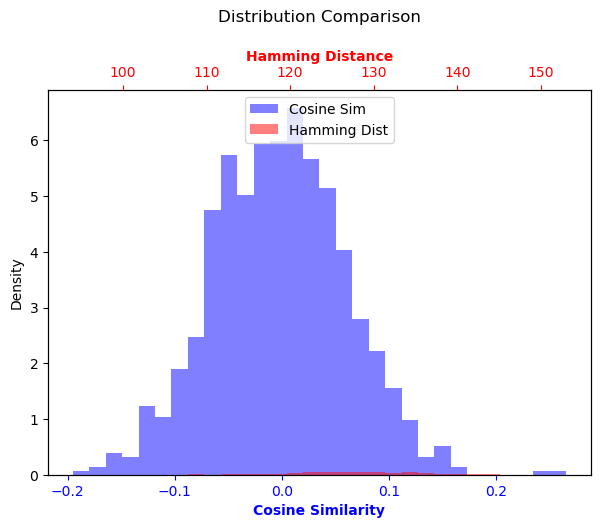

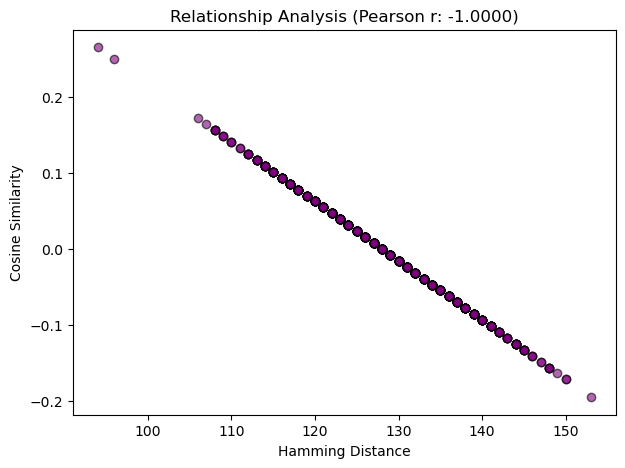

In [3]:
plot_dual_histogram(
    data1=cos_sims, data2=ham_dists,
    label1='Cosine Sim', label2='Hamming Dist',
    xlabel1='Cosine Similarity', xlabel2='Hamming Distance',
    title='Distribution Comparison',
    save_path='../paper/figures/01_distribution.png'
)

plot_correlation_scatter(
    x=ham_dists, y=cos_sims,
    xlabel='Hamming Distance', ylabel='Cosine Similarity',
    title=f'Relationship Analysis (Pearson r: {pearson_r:.4f})',
    save_path='../paper/figures/01_relationship.png'
)